In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

In [2]:
data = pd.read_csv('advertising.csv')
data.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9


In [3]:
data.shape

(200, 4)

In [4]:
data.isnull().sum()


TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64

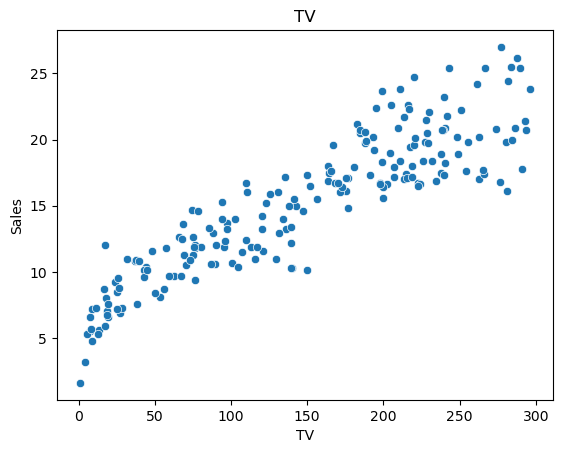

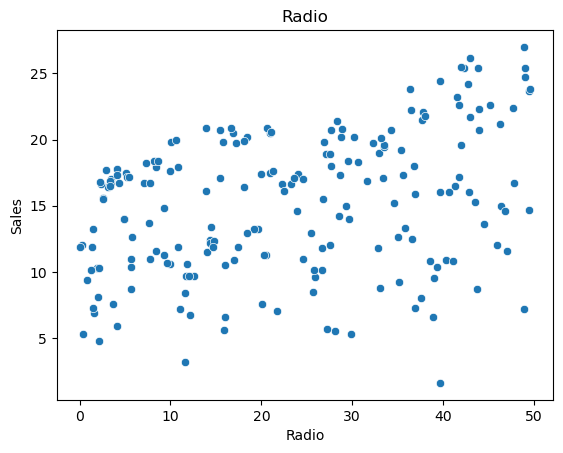

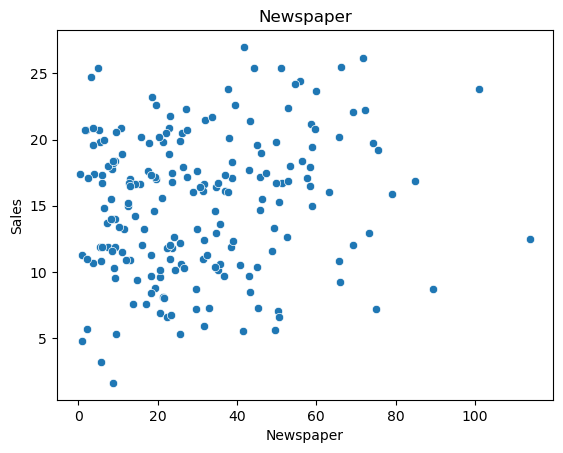

In [5]:
# Distribution of data points

for column_name in data.columns:
    if column_name != 'Sales':
        sns.scatterplot(data=data,x=column_name,y='Sales')
        plt.title(column_name)
        plt.show()

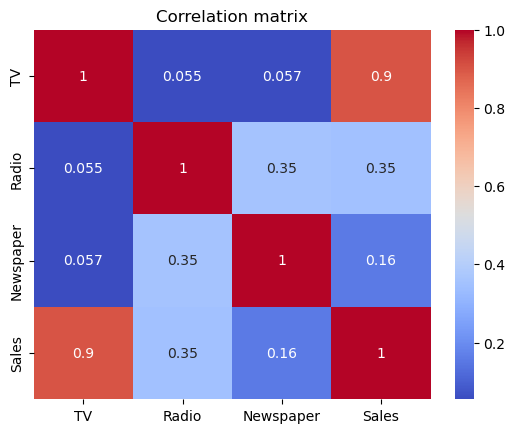

In [6]:
# Heat of Correlations
correlation_matrix = data.corr()
sns.heatmap(correlation_matrix,annot=True,cmap='coolwarm')
plt.title('Correlation matrix')
plt.show()

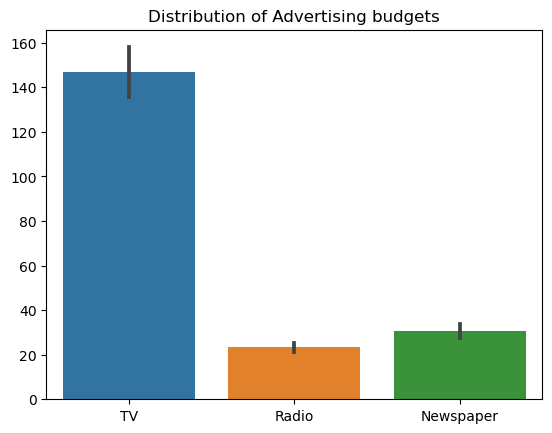

In [7]:
# box plots
sns.barplot(data=data[['TV','Radio','Newspaper']])
plt.title('Distribution of Advertising budgets')
plt.show()

In [8]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
x = data[['TV','Radio','Newspaper']]
y = data['Sales']

# Split the data
x_train,x_test, y_train,y_test = train_test_split(x,y,test_size=0.2, random_state=0)

In [9]:
model = LinearRegression()
model.fit(x_train,y_train)

LinearRegression()

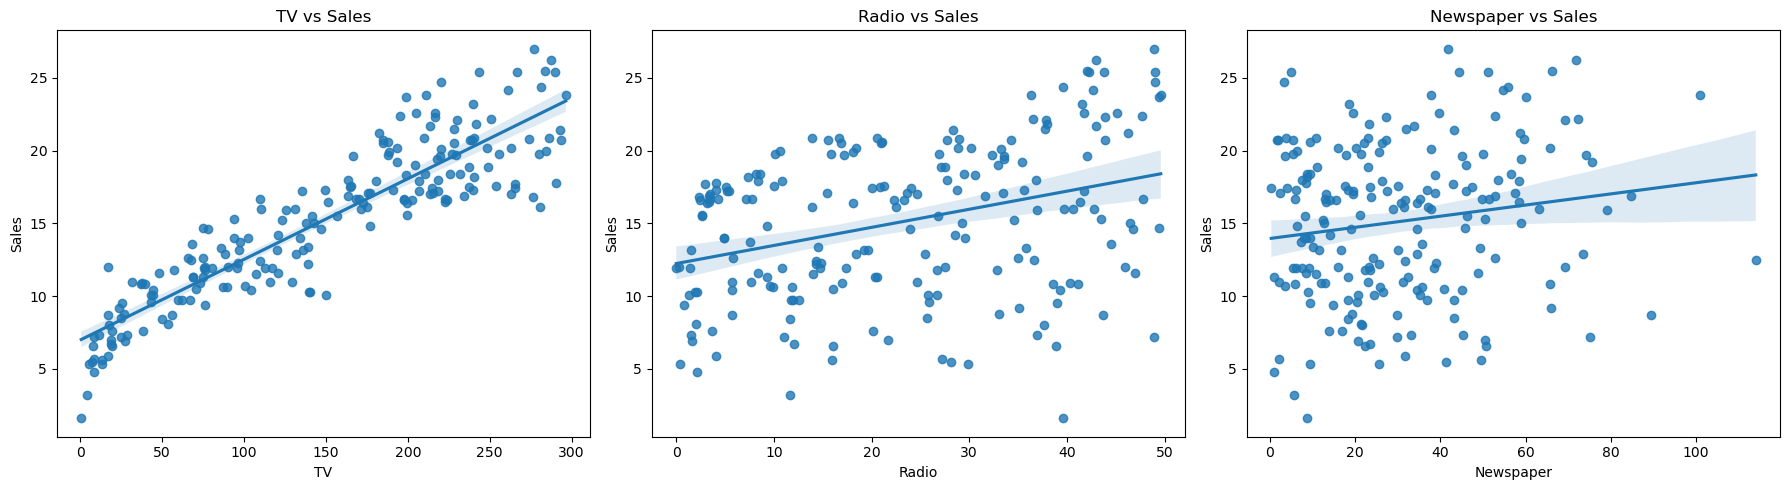

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# TV
sns.regplot(x='TV', y='Sales', data=data, ax=axes[0])
axes[0].set_title('TV vs Sales')

# Sales
sns.regplot(x='Radio', y='Sales', data=data, ax=axes[1])
axes[1].set_title('Radio vs Sales')

# Newspaper
sns.regplot(x='Newspaper', y='Sales', data=data, ax=axes[2])
axes[2].set_title('Newspaper vs Sales')

plt.tight_layout()
plt.show()

In [11]:
y_pred = model.predict(x_test)

In [12]:
from sklearn.metrics import mean_squared_error ,r2_score
r2 = r2_score(y_test,y_pred)
r2

0.8645053923967724

In [13]:
mse = mean_squared_error(y_test,y_pred)
mse

4.522552562041291

In [14]:
rmse = np.sqrt(mse)
rmse

2.1266293899128947

In [15]:
from sklearn.metrics import mean_absolute_percentage_error

error= mean_absolute_percentage_error(y_pred,y_test)
print(f'Accuracy of Linear Regression is %.2f'%((1-error)*100))

Accuracy of Linear Regression is 89.50


In [22]:
from sklearn.preprocessing import PolynomialFeatures
x_train,x_test, y_train,y_test = train_test_split(x,y,test_size=0.2, random_state=0)

poly = PolynomialFeatures(degree=2, include_bias=True)
x_train_trans = poly.fit_transform(x_train)
x_test_trans = poly.transform(x_test)

lr2 = LinearRegression()
lr2.fit(x_train_trans, y_train)
y_pred_2 = lr2.predict(x_test_trans)
print(r2_score(y_test, y_pred))

0.8645053923967724


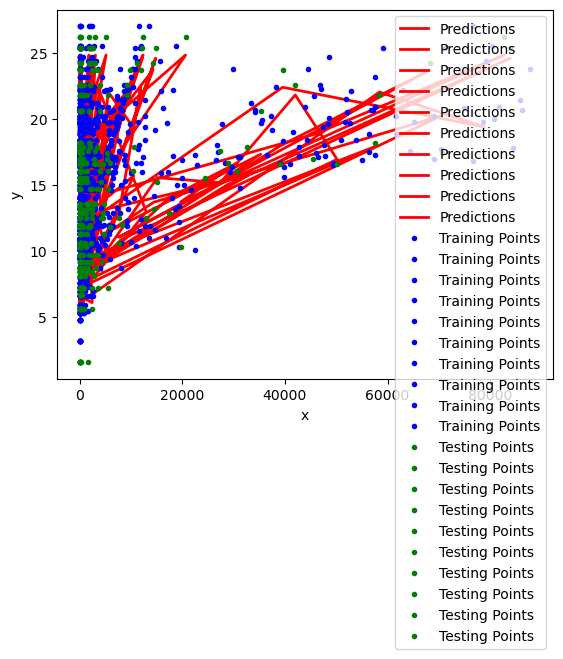

In [23]:
plt.plot(x_test_trans,y_pred_2,"r-",linewidth=2,label="Predictions")
plt.plot(x_train_trans,y_train,"b.",label="Training Points")
plt.plot(x_test_trans,y_test,"g.",label="Testing Points")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

In [27]:
from sklearn.svm import SVR
svc_reg = SVR()
svc_reg.fit(x_train,y_train)

SVR()

In [29]:
y_pred = svc_reg.predict(x_test)
y_pred

array([10.83197701,  9.43199023, 11.13620288, 21.27532831, 15.8142656 ,
        9.53316961, 10.07076148, 18.54588596,  9.74879265, 17.98511076,
       21.18817568, 11.46620759, 14.73731315, 17.36546637, 11.55549349,
       13.77717611, 19.69023632,  8.73798747, 12.79768711, 18.71506103,
       21.11885304, 13.88523437, 16.97798976, 14.41789947,  9.27676809,
       14.79774769, 15.64789174, 19.58580074, 17.76590456,  8.96426241,
       13.11099825, 19.65367591, 20.02280998, 20.49602282,  8.34439983,
        8.16127244, 10.04607181, 16.61452963, 12.059168  ,  8.34429743])

In [31]:
from sklearn.metrics import r2_score
r2_score(y_test,y_pred)

0.8338438785576546

In [32]:
from sklearn.tree import DecisionTreeRegressor
dtr = DecisionTreeRegressor()
dtr.fit(x_train,y_train)

DecisionTreeRegressor()